<a href="https://colab.research.google.com/github/realtommypoole/LLMRAGOptimize/blob/Dev-Branch/AAI_590_20260405.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Title: LLM RAG Distillation & Supervised Fine Tuning Optimization
## Subtitle: Fine tuning open source nano models with larger reasoning models
Author: Tommy Poole, Spring Semester 2026, University of San Diego, Shirley Marcos School of Engineering, Master's in Science of Applied Artificial Intelligence

**Attribution:** Claude code March 29. Perplexity March 29. Microsoft for contextual.



In [1]:
import os
hf_cache = os.path.expanduser("~/.cache/huggingface/hub")

print("HF hub cache exists:", os.path.exists(hf_cache))
!du -sh {hf_cache} 2>/dev/null || echo "no hub cache found"
!du -sh ~/.cache/huggingface/datasets 2>/dev/null || echo "no datasets cache"

HF hub cache exists: False
no hub cache found
no datasets cache


In [2]:
# Remove the entire HF hub cache
!rm -rf /root/.cache/huggingface/hub

# (optional) clean up the datasets cache if it ever appears
!rm -rf /root/.cache/huggingface/datasets

# Remove any dangling .cache metadata
!rm -rf /root/.cache/huggingface/repos

In [3]:
!df - h /


df: -: No such file or directory
df: h: No such file or directory
Filesystem     1K-blocks     Used Available Use% Mounted on
overlay        247124032 46032416 201075232  19% /




---



## Introduction

Retreival Augmented Generation (RAG) helps Large Language Models perform when applied to contexts with specific knowledge, such as enterprise business settings. RAG solutions produce more accurate information by gounding generated answers in a corpus of specific knowledge, vocuabluary, and even way of writing. One way this kind of application can be optimized to produce better answers is with supervised fine tuning, where specific information is used to update weights on the original LLM. This fine tuning, coupled with RAG, can achieve even better results than RAG alone. One of the key questions is exactly how much better this approach can make results.

This project compares fine tuning with different amounts of data across different models. Both agents have access to the same data for reference, but one of them has been fine-tuned with supervised fine tuning on a curated set of question answer pairs. The code is outlined as follows:

1. Import key libraries.
2. Download models from HuggingFace
  - Reasononing Models(Qwen3-Next-80B-Thinking & DeepSeek v3.2 for reasoning tasks)
  - Nano Models (SmolLM3-3B, Nemotron 3 Nano-4B, Llama 4 Maverick)
  - API to Claude 4.6 for comparison
3. Ingest a corpus of data.
4. Generate text embeddings, store in vector store.
5. Use both reasoning models to create 150 question answer pairs each based on the data, convert to JSONL format and combine in one dataset.
6. Create five datasets from those total questions of QA pairs for fine tuning of the following sizes: (40 held out as test), then 256 QA pairs, 64 QA pairs, 32 QA pairs, 8 QA pairs.
7. Fine tune all three nano models with the question answer pairs.
8. Test 40 questions against the three fine tuned models, and all three non fine tuned models, with the same prompt and corpus for reitreival.
9. Use a different reasononing model to evaluate each response against the ground truth for groundedness, relevance, and correctness. Use Microsoft documentation to determine scales (1-5) to match their CoPilot studio evaluation metrics.
10. Generate responses to the 40 questions using the two larger reasoning models, also use Claude as well, and score against same metrics and evaluate.
11. Discussion of results. The primary question for evaluation is whether or not the total number of questions used impacts the fine tuning results. Different nano models are used to ensure it isn't an issue with the nano model selected, but evaluation of QA dataset size can average across each nano model assuming they aren't significantly different.

Key Questions:

**Data Size**
- 256 questions (total token: )
- 64 questions (total token: )
- 32 questions (total token: )
- 8 questions (total token: )


Model Size:

Reasoning:
- Qwen3-Next-80B (150)
- DeepSeek v3.2 (150)

Nano:
- SmolLm
- Nemotron 3 Nano-4B
- Llama 4 Marverick


Compared to Claude:


_

# 1. Import Libraries

**NOTE:** If using Google CoLab, connect to GPU with High Ram.

In [1]:
# Install dependencies (run once)
!pip install transformers datasets huggingface_hub peft trl accelerate bitsandbytes
!pip install sentence-transformers faiss-cpu
!pip install anthropic
!pip install jsonlines tqdm
!pip install pypdf
!pip install matplotlib seaborn
!pip install -q -U google-generativeai
!pip install pdfplumber pymupdf
!pip install --upgrade transformers accelerate bitsandbytes optimum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 630.8/630.8 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 54.8 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 96.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 478.8/478.8 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.7/333.7 kB 8.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# Standard Library
import os
import json
import re
from pathlib import Path
import sklearn
from sklearn.model_selection import train_test_split
import pypdf
import random, time
from peft import PeftModel
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from math import pi
import pdfplumber
import fitz

# Third-party: data & numerics
import numpy as np
import pandas as pd
from tqdm import tqdm
import jsonlines
import gc
import hashlib

# PyTorch
import torch

# HuggingFace: models, tokenizers, datasets
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    pipeline,
)
from datasets import Dataset, load_dataset
from huggingface_hub import login as hf_login

# HuggingFace: fine-tuning (PEFT / SFT)
from peft import LoraConfig, get_peft_model, TaskType
from trl import SFTTrainer, SFTConfig

# Embeddings & vector store
from sentence_transformers import SentenceTransformer
import faiss

# Anthropic (Claude)
import anthropic

# Gemini
from google import genai
from google.genai import types

# Google CoLab
from google.colab import userdata

# Sanity check (print for check)
print(f"PyTorch version : {torch.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU name   : {torch.cuda.get_device_name(0)}")


PyTorch version : 2.10.0+cu128
Using device: cuda
GPU name   : NVIDIA RTX PRO 6000 Blackwell Server Edition


# 2. Model Setup & API Connections

In [17]:
# API Keys
HF_TOKEN      = userdata.get("HF_TOKEN")
ANTHROPIC_API_KEY = userdata.get("ANTHROPIC_KEY")
GEMINI_API_KEY    = userdata.get("GEMINI")

# --- Reasoning Models (QA generation + baseline inference) ---
REASONING_MODELS = {
    "qwen"     : "Qwen/Qwen3-8B",    # Issues with thinking model
    "gemma"    : "google/gemma-4-26B-A4B-it", # released early April, 2026
}

# --- Nano Models (fine-tune targets) ---
NANO_MODELS = {
    "smollm"   : "HuggingFaceTB/SmolLM3-3B",
    "nemotron" : "nvidia/Nemotron-Mini-4B-Instruct",
    "llamaNano"    : "meta-llama/Llama-3.2-1B-Instruct",
}

# LoRA target modules — override per model if architecture differs
LORA_TARGETS = {
    "smollm"   : ["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
    "nemotron" : ["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
    "llamaNano"    : ["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
}

# --- Dataset sizes for SFT comparison ---
DATASET_SIZES = [256, 64, 32, 8]
NUM_TEST      = 40        # held-out questions (never used in training)

# --- Output directories ---
QA_DIR      = Path("data/qa")
MODELS_DIR  = Path("models")
RESULTS_DIR = Path("data/results")
EVAL_DIR    = Path("data/eval")
for d in [QA_DIR, MODELS_DIR, RESULTS_DIR, EVAL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# --- API Connections ---
hf_login(token=HF_TOKEN)
print("HuggingFace login : OK")

# Claude
claude_client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)
CLAUDE_MODEL  = "claude-sonnet-4-6"
_ping = claude_client.messages.create(
    model=CLAUDE_MODEL, max_tokens=16,
    messages=[{"role": "user", "content": "Reply OK"}],
)
print(f"Claude connected  : {_ping.content[0].text.strip()}")

# Gemini
gemini_client = genai.Client(api_key=GEMINI_API_KEY)
GEMINI_MODEL = "gemini-3-flash-preview"

_ping = gemini_client.models.generate_content(
    model=GEMINI_MODEL,
    contents="Reply OK",
)

print(f"Gemini connected  : {_ping.text.strip()}")

# --- Shared 4-bit quantization config ---
bnb_4bit = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
    llm_int8_enable_fp32_cpu_offload=True,
    llm_int8_threshold=6.0,
)

print("\n✅ Config complete — models load on demand in later sections.")


HuggingFace login : OK
Claude connected  : OK
Gemini connected  : OK

✅ Config complete — models load on demand in later sections.


# 3. Corpus Ingestion

In [4]:
DATASET_DIR   = Path("data")
CHUNK_SIZE    = 384
CHUNK_OVERLAP = 96


def load_corpus_chunks(chunks_path: Path):
    if chunks_path.exists():
        with jsonlines.open(chunks_path) as f:
            chunks = list(f)
        print(f"✅ Loaded {len(chunks):,} saved chunks from {chunks_path}")
        return chunks
    return None


def extract_text_from_pdf(pdf_path: Path) -> str:
    text_parts = []
    try:
        with pdfplumber.open(str(pdf_path)) as pdf:
            num_pages = len(pdf.pages)
            print(f"  Extracting {pdf_path.name} ({num_pages:,} pages)...")
            for i, page in enumerate(pdf.pages):
                page_text = page.extract_text() or ""
                if page_text.strip():
                    text_parts.append(f"--- Page {i+1} ---\n{page_text}")
                page.flush_cache()
                if (i + 1) % 100 == 0:
                    print(f"    Page {i+1}/{num_pages}")
            full_text = "\n\n".join(text_parts)
            print(f"  {pdf_path.name}: {num_pages:,} pages → {len(full_text):,} chars")
            return full_text
    except Exception as e:
        print(f"  pdfplumber failed: {e}")

    try:
        doc = fitz.open(str(pdf_path))
        num_pages = len(doc)
        print(f"  Falling back to PyMuPDF for {pdf_path.name} ({num_pages:,} pages)...")
        for i, page in enumerate(doc):
            page_text = page.get_text()
            if page_text.strip():
                text_parts.append(f"--- Page {i+1} ---\n{page_text}")
            if (i + 1) % 100 == 0:
                print(f"    Page {i+1}/{num_pages}")
        doc.close()
        full_text = "\n\n".join(text_parts)
        print(f"  {pdf_path.name}: {num_pages:,} pages → {len(full_text):,} chars")
        return full_text
    except Exception as e:
        print(f"  PyMuPDF failed: {e}")
        return f"[EXTRACTION FAILED: {pdf_path.name}]"


def chunk_text(text: str, chunk_size: int = CHUNK_SIZE, overlap: int = CHUNK_OVERLAP) -> list[str]:
    paragraphs = re.split(r'\n\s*\n|\n#{1,3}\s', text)
    chunks = []
    for para in paragraphs:
        para = para.strip()
        if not para:
            continue
        if len(para) <= chunk_size:
            chunks.append(para)
        else:
            start = 0
            while start < len(para):
                chunk = para[start:start + chunk_size].strip()
                if chunk:
                    chunks.append(chunk)
                start += chunk_size - overlap
    return [c for c in chunks if len(c) > 50]


chunks_file = DATASET_DIR / "corpus_chunks.jsonl"
corpus_chunks = load_corpus_chunks(chunks_file)

if corpus_chunks is None:
    pdf_files = sorted(DATASET_DIR.glob("*.pdf"))
    assert pdf_files, f"No PDFs found in {DATASET_DIR.resolve()}"

    corpus_chunks = []
    for pdf_path in pdf_files:
        raw_text = extract_text_from_pdf(pdf_path)
        chunks = chunk_text(raw_text)
        for i, chunk in enumerate(chunks):
            corpus_chunks.append({
                "source": pdf_path.name,
                "chunk_id": i,
                "text": chunk
            })
        print(f"  → {len(chunks):,} chunks from {pdf_path.name}")

    with jsonlines.open(chunks_file, "w") as f:
        f.write_all(corpus_chunks)
    print(f"💾 Saved {len(corpus_chunks):,} chunks to {chunks_file}")

_count_tok = AutoTokenizer.from_pretrained(list(NANO_MODELS.values())[0], token=HF_TOKEN)
total_tokens = 0
total_chars = 0
for chunk in corpus_chunks:
    total_chars += len(chunk["text"])
    total_tokens += len(_count_tok(chunk["text"], add_special_tokens=False)["input_ids"])
del _count_tok

print(f"  Avg chunk tokens: {total_tokens / len(corpus_chunks):.0f}")

samples = random.sample(corpus_chunks, min(5, len(corpus_chunks)))
print("\n=== 5 RANDOM CHUNK SAMPLES ===")
for i, chunk in enumerate(samples, 1):
    print(f"\n{i}. {chunk['source']} (chunk {chunk['chunk_id']})")
    print(f"   {repr(chunk['text'][:200])}...")

print(f"\n=== CORPUS SUMMARY ===")
print(f"  PDFs loaded   : {len(set(c['source'] for c in corpus_chunks))}")
print(f"  Total chunks  : {len(corpus_chunks):,}")
print(f"  Total chars   : {total_chars:,}")
print(f"  Total tokens  : {total_tokens:,}")

  Extracting Artificial Intelligence - A Modern Approach (3rd Edition).pdf (1,151 pages)...
    Page 100/1151
    Page 200/1151
    Page 300/1151
    Page 400/1151
    Page 500/1151
    Page 600/1151
    Page 700/1151
    Page 800/1151
    Page 900/1151
    Page 1000/1151
    Page 1100/1151
  Artificial Intelligence - A Modern Approach (3rd Edition).pdf: 1,151 pages → 3,289,518 chars
  → 11,773 chunks from Artificial Intelligence - A Modern Approach (3rd Edition).pdf
💾 Saved 11,773 chunks to data/corpus_chunks.jsonl


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

  Avg chunk tokens: 102

=== 5 RANDOM CHUNK SAMPLES ===

1. Artificial Intelligence - A Modern Approach (3rd Edition).pdf (chunk 5610)
   'aps actual\nx\nhandedness turns out mostly the same (with some probability s) as the gene an individual\npossesses. Furthermore, perhaps the gene itself is equally likely to be inherited from either\nofan'...

2. Artificial Intelligence - A Modern Approach (3rd Edition).pdf (chunk 11763)
   ',356,1075 Wood,D.E.,111,1080\nwasp,sphex,39,425 Whitehead,A.N.,16,357,781,1092 Woods,W.A.,471,921,1092\nWasserman,L.,763,1091 Whiter,A.M.,431,1090 Wooldridge,M.,60,61,1068,1092\nWatkins,C.J.,685,855,1091'...

3. Artificial Intelligence - A Modern Approach (3rd Edition).pdf (chunk 502)
   'nt good or bad,\nintelligent orstupid? Weanswerthesequestions inthenextsection.\n1 Iftheagentusessomerandomizationtochoose itsactions, thenwewouldhavetotryeachsequence many\ntimestoidentifytheprobability'...

4. Artificial Intelligence - A Modern Approach (3rd Edition).pdf (chu

**Run Notes:**




Run 3/29/26 (Microsoft Foundry Corpus) -
- 26,281 characters, 5,657 tokens
- 57 chunks, 25,866 chars, 5,568 tokens


Run 4/1/26 (AI Textbook Corpus) -
- 83 chunks, 42,309 chars, 13,705 tokens
- (removed page limit) 11,773 chunks, 4m chars, 1.2m tokens

Run 4/2/26
- 11,773 chunks, 4.3m chars, 1.2m tokens

# 4. Embeddings & Vector Store

Using Facebook AI Similarity Search for effecient similarity searching.

In [5]:
# Config
EMBED_MODEL_ID = "all-MiniLM-L6-v2"   # fast, reliable; can swap for larger model if needed
TOP_K          = 5                     # default chunks to retrieve per query

# Load embedding model
print(f"Loading embedding model: {EMBED_MODEL_ID} ...")
embed_model = SentenceTransformer(EMBED_MODEL_ID)
EMBED_DIM   = embed_model.get_sentence_embedding_dimension()
print(f"Embedding dimension: {EMBED_DIM}")

# Encode corpus chunks
print(f"Encoding {len(corpus_chunks):,} chunks ...")
chunk_texts = [c["text"] for c in corpus_chunks]

chunk_embeddings = embed_model.encode(
    chunk_texts,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True,   # required for cosine similarity via inner product
    convert_to_numpy=True,
)

# Build FAISS index (cosine similarity via inner product on normalized vecs)
faiss_index = faiss.IndexFlatIP(EMBED_DIM)
faiss_index.add(chunk_embeddings)
print(f"FAISS index built: {faiss_index.ntotal:,} vectors")

# Retrieval helper
def retrieve(query: str, k: int = TOP_K) -> list[dict]:
    """Return the top-k most relevant corpus chunks for a given query."""
    query_vec = embed_model.encode(
        [query],
        normalize_embeddings=True,
        convert_to_numpy=True,
    )
    scores, indices = faiss_index.search(query_vec, k)
    results = []
    for score, idx in zip(scores[0], indices[0]):
        results.append({**corpus_chunks[idx], "score": float(score)})
    return results

# Smoke Test - Simple question to see how well it worked
test_query   = "What is artificial intelligence?"
test_results = retrieve(test_query)

print ("\n\n\n=== SMOKE TEST ===")
print(f"\nSmoke test — query: '{test_query}'")
for r in test_results:
    print(f"  [{r['score']:.3f}] {r['source']} chunk {r['chunk_id']}: {r['text'][:80]}...")


Loading embedding model: all-MiniLM-L6-v2 ...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding dimension: 384
Encoding 11,773 chunks ...


Batches:   0%|          | 0/184 [00:00<?, ?it/s]

FAISS index built: 11,773 vectors
=== SMOKE TEST ===

Smoke test — query: 'What is artificial intelligence?'
  [0.686] Artificial Intelligence - A Modern Approach (3rd Edition).pdf chunk 127: so important
INTELLIGENCE
tous. Forthousands ofyears, wehavetried tounderstand h...
  [0.666] Artificial Intelligence - A Modern Approach (3rd Edition).pdf chunk 426: r,inSimon’swords,“machinesthatthink,thatlearn
andthatcreate.” Theycalltheeffort ...
  [0.653] Artificial Intelligence - A Modern Approach (3rd Edition).pdf chunk 452: ords(Brants etal.,2007). Noneofthecomputerscientists
ontheteamspeakArabic,butthe...
  [0.630] Artificial Intelligence - A Modern Approach (3rd Edition).pdf chunk 321: es. The second answer is methodology. AI is the only one
ofthesefieldsthatisclea...
  [0.622] Artificial Intelligence - A Modern Approach (3rd Edition).pdf chunk 126: --- Page 20 ---
1
INTRODUCTION
In which we try to explain why we consider artifi...


# 5. QA Pair Generation & Evaluation

A. Question Generation
- Generates QA pairs from BOTH reasoning models and saves to QA_DIR.
- Per-model JSONL files cached on disk — skips generation if found.
- Set FORCE_REGEN=True to regenerate from scratch.

B. Question Subsets
- Create five QA subsets of different sizes (256, 64, 32, 8)

### A. Generation

In [6]:
# Config
FORCE_REGEN = False
MAX_NEW_TOKENS = 192 # experimented with 96, 192
SEED = 24
random.seed(SEED)

MIN_VALID_QA_PER_MODEL = 200 # upped from 150 to have 30% over total used
SAMPLE_CHUNK_SIZE = 200
BATCH_SIZE = 8

QA_DIR = Path("./qa_outputs")
QA_DIR.mkdir(parents=True, exist_ok=True)

combined_file = QA_DIR / "qa_combined.jsonl"

results = {}

In [7]:
# Model registry

MODEL_SPECS = {
    "gemma": {
        "backend": "hf_local",
        "model_id": REASONING_MODELS["gemma"],
        "temperature": 0.3,
        "do_sample": False,
        "prompt_template": """Generate EXACTLY ONE question-answer pair as valid JSON.
No explanation, no markdown, no extra text.

Return exactly:
{{"question": "Your question?", "answer": "Your answer from passage only"}}

Use only the passage below.

PASSAGE:
{passage}
""",
        "debug_raw": False,
    },

    "qwen": {
        "backend": "hf_local",
        "model_id": REASONING_MODELS["qwen"],
        "temperature": 0.0,
        "do_sample": False,
        "prompt_template": """<|im_start|>system
Respond with ONLY this JSON: {{"question": "?", "answer": "?"}}
No thinking. No explanation. No other text.

<|im_start|>user

{passage}<|im_end|>

<|im_start|>assistant

""",
        "debug_raw": True,
    }
}

ACTIVE_MODELS = ["gemma", "qwen"]

# Stable per-model seed offsets to include reproducibility without repeated questions
MODEL_SEED_OFFSETS = {
    "gemma": 101,
    "qwen": 202,
}

In [8]:
# --- Helper Functions ---

# Generate stable integer hash from text
def stable_int_hash(text: str, mod: int = 10_000) -> int:
    digest = hashlib.md5(text.encode("utf-8")).hexdigest()
    return int(digest[:8], 16) % mod

# Create reproducible Random instance per model
# Ensures same passage order across runs, but diffent models get different questions
def get_model_rng(model_key: str) -> random.Random:
    offset = MODEL_SEED_OFFSETS.get(model_key, stable_int_hash(model_key))
    return random.Random(SEED + offset)

# Load JSONL file list of dicts
def load_jsonl(path: Path) -> list[dict]:
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

# Save list of JSONL Files, one JSON object per line
def save_jsonl(path: Path, rows: list[dict]) -> None:
    with open(path, "w", encoding="utf-8") as f:
        for row in rows:
            f.write(json.dumps(row, ensure_ascii=False) + "\n")

# Merge per model QA results & assign sequential global IDs
def assign_global_ids(results_dict: dict[str, list[dict]]) -> list[dict]:
    all_rows = []
    gid = 0
    for model_key, rows in results_dict.items():
        for row in rows:
            item = dict(row)
            item["global_id"] = gid
            all_rows.append(item)
            gid += 1
    return all_rows

# --- JSON Parser ---
# Parse raw model output into clean {"question","answer"} or None
def extract_json(text: str) -> dict | None:
    patterns = [
        r'\{.*?"question".*?"answer".*?\}', # make robust, extract only question and answer
        r'\{[^{}]*\}',
    ]
    for pattern in patterns:
        for m in re.findall(pattern, text, re.DOTALL):
            try:
                parsed = json.loads(m)
                if (
                    isinstance(parsed, dict)
                    and isinstance(parsed.get("question"), str)
                    and isinstance(parsed.get("answer"), str)
                    and parsed["question"].strip()
                    and parsed["answer"].strip()
                ):
                    return {
                        "question": parsed["question"].strip(),
                        "answer": parsed["answer"].strip(),
                    }
            except json.JSONDecodeError:
                continue
    return None

# --- Prompt Builder ---
def build_prompts(tok, model_key: str, batch: list[dict]) -> list[str]:
    spec = MODEL_SPECS[model_key] # find the model distinct
    template = spec["prompt_template"]
    prompts = []

    for p in batch:
        user_prompt = template.format(passage=p["text"].strip())
        messages = [{"role": "user", "content": user_prompt}]

        # apply_chat_template requires the tokenizer to have a chat template
        prompt = tok.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )
        prompts.append(prompt)

    return prompts

# --- Load / Unload Models---
# To free GPU space in environment
def load_generator(model_key: str):
    spec = MODEL_SPECS[model_key]
    backend = spec["backend"]

    if backend != "hf_local":
        return None, None

    model_id = spec["model_id"]
    print(f"Loading model [{model_key}]: {model_id}")

    tok = AutoTokenizer.from_pretrained(
        model_id,
        token=HF_TOKEN,
        trust_remote_code=True,
    )

    mdl = AutoModelForCausalLM.from_pretrained(
        model_id,
        quantization_config=bnb_4bit, # 4-bit compressor, memory saver
        device_map="auto", # auto GPU placement
        trust_remote_code=True, # allow models with custom python code
        token=HF_TOKEN,
    )
    mdl.eval()

    if tok.pad_token is None:
        tok.pad_token = tok.eos_token

    # More reliable for decoder-only batched generation
    tok.padding_side = "left"

    return tok, mdl

# Model Unload function to clear space
def unload_generator(tok, mdl):
    if mdl is not None:
        del mdl
    if tok is not None:
        del tok
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

# --- Backend Generators ---
def generate_batch_hf(
    model_key: str,
    tok,
    mdl,
    batch: list[dict],
    qa_pairs: list[dict],
) -> list[dict]:
    spec = MODEL_SPECS[model_key]
    prompts = build_prompts(tok, model_key, batch)

    inputs = tok(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
    ).to(mdl.device)

    temperature = spec.get("temperature", 0.3) # only assigns .3 if not defined in MODEL_SPEC
    do_sample = spec.get("do_sample", False) # greedy decoding (deterministic)

    with torch.no_grad(): # disables gradients, not needed for generating QA pairs, saves memory
        outputs = mdl.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            temperature=temperature,
            do_sample=do_sample,
            pad_token_id=tok.pad_token_id,
            eos_token_id=tok.eos_token_id,
        )

    new_rows = [] # list to collect valid QA pairs

    for j, (p, output) in enumerate(zip(batch, outputs)):
        # Use true prompt length from attention mask, not padded width
        prompt_len = int(inputs["attention_mask"][j].sum().item()) # handles variable prompt length
        new_ids = output[prompt_len:]
        raw = tok.decode(new_ids, skip_special_tokens=True).strip()

        if spec.get("debug_raw", False) and j < 3:
            print(f"[DEBUG {model_key} raw] {repr(raw[:300])}")

        qa = extract_json(raw) # filters out bad model responses
        if qa:
            new_rows.append({
                "id": len(qa_pairs) + len(new_rows),
                "question": qa["question"], # extracted question
                "answer": qa["answer"], # extracted answer
                "source": p["source"],
                "chunk_id": p["chunk_id"],
                "source_text": p["text"],
                "generator": model_key, # which model made it
            })

    return new_rows

# --- Dispatcher ---
# To run models with correct model execution engine
def generate_batch(
    model_key: str,
    tok,
    mdl,
    batch: list[dict],
    qa_pairs: list[dict],
) -> list[dict]:
    backend = MODEL_SPECS[model_key]["backend"]

    if backend == "hf_local":
        return generate_batch_hf(model_key, tok, mdl, batch, qa_pairs) # local HF model
    else:
        raise ValueError(f"Unknown backend for {model_key}: {backend}")

# --- Generate ---
# Generate QA until target
def generate_until_target(
    model_key: str, # determine model
    passages: list[dict], # input corpus chunks to generate QA from
    min_valid: int = MIN_VALID_QA_PER_MODEL, # stop when minimum threshold is met
    sample_chunk_size: int = SAMPLE_CHUNK_SIZE, # how many passages to sample per iteration
    batch_size: int = BATCH_SIZE, # how many passages to sample per iteration
):

    print(f"loading {model_key}...")
    tok, mdl = load_generator(model_key) # returns None, None for API models if used

    try:
        # Create reproducible random order for passing samplying, unique seed for each model
        rng = get_model_rng(model_key) # deterministic RNG per model
        pool = passages[:]  # copy full passage list
        rng.shuffle(pool) # shuffle, in a reproducible way

        qa_pairs = [] # accuumlate valid QA Pairs
        cursor = 0 # track position in shuffled pool

        with tqdm(total=min_valid, desc=f"QA gen [{model_key}]") as pbar:
            # Keep sampling until target hit or passages exhausted
            while len(qa_pairs) < min_valid and cursor < len(pool):
                sample = pool[cursor:cursor + sample_chunk_size]
                cursor += sample_chunk_size
                # Process sample in smaller batches (for memory/batching effeciency)
                for i in range(0, len(sample), batch_size):
                    batch = sample[i:i + batch_size]
                    rows = generate_batch(model_key, tok, mdl, batch, qa_pairs)
                    qa_pairs.extend(rows) # add any vaid pairs found

                    # Update progress bar
                    pbar.n = min(len(qa_pairs), min_valid)
                    pbar.refresh()

                    if len(qa_pairs) >= min_valid:
                        break

        print(f"[{model_key}] Generated {len(qa_pairs)} valid pairs")
        return qa_pairs[:min_valid] # return exactly target count

    finally:
        unload_generator(tok, mdl) # critical cleanup step to clear GPU memory
        print(f"[{model_key}] Model unloaded")


In [9]:
# --- Cache/load Wrapper ---
def run_model(model_key: str, passages: list[dict]) -> list[dict]:
    out_file = QA_DIR / f"qa_{model_key}.jsonl"

    if out_file.exists() and not FORCE_REGEN:
        print(f"[{model_key}] Loading cached QA")
        return load_jsonl(out_file)

    rows = generate_until_target(
        model_key=model_key,
        passages=passages,
        min_valid=MIN_VALID_QA_PER_MODEL,
    )
    save_jsonl(out_file, rows)
    return rows

In [11]:
# Run Gemma, separate from others
print("=== GEMMA ===")
results["gemma"] = run_model("gemma", corpus_chunks)

=== GEMMA ===
Loading model [gemma]: google/gemma-4-26B-A4B-it


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1013 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]


QA gen [gemma]:   0%|          | 0/150 [00:00<?, ?it/s]The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.

QA gen [gemma]: 100%|██████████| 150/150 [03:54<00:00,  1.57s/it]


[gemma] Generated 152 valid pairs
[gemma] Model unloaded
Press Enter to continue to Qwen...


''

In [12]:
# Run Qwen separately
print("=== QWEN ===")
results["qwen"] = run_model("qwen", corpus_chunks)

=== QWEN ===
Loading model [qwen]: Qwen/Qwen3-8B


config.json:   0%|          | 0.00/728 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

[DEBUG qwen raw] ')\nThisequation provid\nassistant\n\nassistant\n<think>\n\n</think>\n\n{"question": "What is the relationship between the B matrices in equations (15.14) and (15.15)?", "answer": "The relationship is given by B t−d+2:t+1 = O − t− 1 d+1 T −1B t−d+1:t TO t+1."}'
[DEBUG qwen raw] 'assistant\n<think>\n\n</think>\n\n{"question": "34", "answer": "2.2 GoodBehavior: TheConceptofRationality"}'
[DEBUG qwen raw] 'ofrainthree days\nfromnow,givenalltheobservationstodate. Predictionisusefulforevaluatingpossible\ncoursesofactionbasedontheirexpectedo\nassistant\n\nassistant\n<think>\n\n</think>\n\n{"question": "What is the task of prediction in the context of computing the posterior distribution over the future state?", "a'



QA gen [qwen]: 100%|██████████| 150/150 [01:08<00:00,  2.18it/s]

[DEBUG qwen raw] '15.20), wealsohavetheproperty thatthevariance update isindep\nassistant\n\nassistant\n<think>\n\n</think>\n\n{"question": "What is the term z − HFμ representing in the context of the prediction error?", "answer": "The term z − HFμ represents the error in the predicted observation."}'
[DEBUG qwen raw] ',andtoothache inthepreceding section are\nabbreviations of this kind.) As in CSPs, domains can be sets of arbitrary tokens; we might\nchoose the domain of\nassistant\n\nassistant\n<think>\n\n</think>\n\n{"question": "What is the abbreviation for propositions of the form A=true?", "answer": "a"}'
[DEBUG qwen raw] '<think>\n\n</think>\n\n{"question": "What is the weight after considering the evidence variables and sampling?", "answer": "0.5"}'
[qwen] Generated 156 valid pairs


[qwen] Model unloaded
Press Enter to continue to Gemini...


''

In [13]:
# --- Combine & Print ---

# Combine all QA pairs
all_qa_pairs = assign_global_ids(results)
save_jsonl(combined_file, all_qa_pairs)

# Print Length & Samples
print(f"Combined file: {combined_file}")
print(f"Total QA pairs: {len(all_qa_pairs):,}")
print(f"File size: {combined_file.stat().st_size / 1e6:.1f} MB")

# Per-model breakdown
print("\nPer-model counts:")
for model, pairs in results.items():
    print(f"  {model:8}: {len(pairs):3} pairs")

# 20 random examples
print("\n🧪 20 RANDOM SAMPLES:")
print("-" * 80)
rng = random.Random(SEED)
sample_indices = rng.sample(range(len(all_qa_pairs)), min(20, len(all_qa_pairs)))

for i, idx in enumerate(sample_indices):
    pair = all_qa_pairs[idx]
    model = pair.get("generator", "unknown")
    print(f"{i+1:2d}. [{model:6}] Q: {pair['question'][:80]}...")
    print(f"      A: {pair['answer'][:80]}...")
    print()

print(f"📊 Full dataset ready: {combined_file}")

Combined file: qa_outputs/qa_combined.jsonl
Total QA pairs: 300
File size: 0.2 MB

Per-model counts:
  gemma   : 150 pairs
  qwen    : 150 pairs

🧪 20 RANDOM SAMPLES:
--------------------------------------------------------------------------------
 1. [qwen  ] Q: What is the main difference between the search strategies described in the text?...
      A: The main difference is the level of resource allocation and the number of releva...

 2. [qwen  ] Q: What is the term z − HFμ representing in the context of the prediction error?...
      A: The term z − HFμ represents the error in the predicted observation....

 3. [gemma ] Q: What does the environment history represent for now?...
      A: the sum of the rewards received...

 4. [gemma ] Q: What is the likelihood of any path?...
      A: the product of the transition probabilities along the path and the probabilities...

 5. [gemma ] Q: Under what condition can the four-wheel conclusion be retracted?...
      A: Ifnewevidence arrives

## B. Split Questions into different sized groupings

In [15]:
# Config B. Dataset Splitting
# Creates four sized training splits (256 / 64 / 32 / 8) and the 40-question
# held-out test set. All written to disk — re-run without regenerating QA.

SPLITS_DIR = QA_DIR / "splits"
SPLITS_DIR.mkdir(exist_ok=True)

# Load combined QA from disk if not already in memory
if "all_qa_pairs" not in dir() or not all_qa_pairs:
    with jsonlines.open(QA_DIR / "qa_combined.jsonl") as reader:
        all_qa_pairs = list(reader)
    print(f"Loaded {len(all_qa_pairs)} QA pairs from disk.")

random.seed(SEED)
shuffled   = all_qa_pairs.copy()
random.shuffle(shuffled)

# Reserve NUM_TEST for held-out test set
test_pairs = shuffled[:NUM_TEST]
train_pool = shuffled[NUM_TEST:]  # 260 available for training splits

# Save test set
test_file = SPLITS_DIR / "test_40.jsonl"
with jsonlines.open(test_file, mode="w") as writer:
    writer.write_all(test_pairs)
print(f"Test set  ({len(test_pairs):>3} questions) → {test_file}")

# Create and save each training split
train_splits = {}
for size in DATASET_SIZES:
    n      = min(size, len(train_pool))
    subset = train_pool[:n]
    train_splits[size] = subset
    split_file = SPLITS_DIR / f"train_{size}.jsonl"
    with jsonlines.open(split_file, mode="w") as writer:
        writer.write_all(subset)
    print(f"  Train [{size:>3}q] → {split_file}  ({len(subset)} pairs)")

print(f"\n✅ All splits saved to {SPLITS_DIR}")
print(f"   Training sizes: {[len(v) for v in train_splits.values()]} | Test: {len(test_pairs)}")


Test set  ( 40 questions) → qa_outputs/splits/test_40.jsonl
  Train [256q] → qa_outputs/splits/train_256.jsonl  (256 pairs)
  Train [ 64q] → qa_outputs/splits/train_64.jsonl  (64 pairs)
  Train [ 32q] → qa_outputs/splits/train_32.jsonl  (32 pairs)
  Train [  8q] → qa_outputs/splits/train_8.jsonl  (8 pairs)

✅ All splits saved to qa_outputs/splits
   Training sizes: [256, 64, 32, 8] | Test: 40


# 6. Supervised Fine-Tuning (LoRA + SFT)

- Fine-tunes every nano model on every dataset size: 3 models × 4 sizes = 12 runs.
- Completed runs are skipped unless FORCE_RETRAIN=True.
- Each fine-tuned model saved to: models/{nano_key}_ft_{size}q/

In [21]:
# Config

FORCE_RETRAIN = False

# --- LoRA hyperparameters ---
LORA_R        = 16
LORA_ALPHA    = 32
LORA_DROPOUT  = 0.05

# --- Training hyperparameters ---
NUM_EPOCHS    = 3
BATCH_SIZE    = 4
GRAD_ACCUM    = 4        # effective batch size = 16
LEARNING_RATE = 2e-4
MAX_SEQ_LEN   = 512
TRAIN_SPLIT   = 0.9

# --- Load splits from disk ---
QA_DIR = Path("qa_outputs")
SPLITS_DIR = QA_DIR / "splits"

with jsonlines.open(SPLITS_DIR / "test_40.jsonl") as r:
    test_pairs = list(r)

train_splits = {}
for size in DATASET_SIZES:
    with jsonlines.open(SPLITS_DIR / f"train_{size}.jsonl") as r:
        train_splits[size] = list(r)

print(f"Test set  : {len(test_pairs)} questions")
for size, pairs in train_splits.items():
    print(f"  Train [{size:>3}q]: {len(pairs)} pairs")


def format_chat(pair: dict, tokenizer) -> str:
    messages = [
        {"role": "user",      "content": pair["question"]},
        {"role": "assistant", "content": pair["answer"]},
    ]
    return tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=False,
    )


def run_sft(nano_key: str, nano_id: str, size: int, pairs: list[dict]) -> Path:
    """Fine-tune one nano model on one dataset size. Saves adapter + tokenizer to disk."""
    out_dir = MODELS_DIR / f"{nano_key}_ft_{size}q"

    if out_dir.exists() and not FORCE_RETRAIN:
        print(f"  ⏭  Skipping {nano_key} × {size}q — checkpoint exists at {out_dir}")
        return out_dir

    print(f"\n{'─'*60}")
    print(f"  Fine-tuning : {nano_key} | dataset size : {size}q")
    print(f"  Model ID    : {nano_id}")
    print(f"{'─'*60}")

    # Load base model + tokenizer
    tok = AutoTokenizer.from_pretrained(nano_id, token=HF_TOKEN)
    tok.pad_token = tok.eos_token

    base_model = AutoModelForCausalLM.from_pretrained(
        nano_id, torch_dtype=torch.bfloat16,
        device_map="auto", token=HF_TOKEN,
    )

    # Format & split
    texts = [format_chat(p, tok) for p in pairs]
    train_texts, val_texts = train_test_split(
        texts, train_size=TRAIN_SPLIT, random_state=SEED
    )
    train_ds = Dataset.from_dict({"text": train_texts})
    val_ds   = Dataset.from_dict({"text": val_texts})

    # LoRA
    lora_cfg = LoraConfig(
        r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=LORA_DROPOUT,
        target_modules=LORA_TARGETS[nano_key],
        task_type=TaskType.CAUSAL_LM, bias="none",
    )
    ft_model = get_peft_model(base_model, lora_cfg)
    ft_model.print_trainable_parameters()

    # Training config
    sft_cfg = SFTConfig(
        output_dir=str(out_dir),
        logging_dir=str(MODELS_DIR / "logs"),
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACCUM,
        learning_rate=LEARNING_RATE,
        lr_scheduler_type="cosine",
        warmup_ratio=0.05,
        bf16=True,
        max_length=MAX_SEQ_LEN,
        dataset_text_field="text",
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        logging_steps=10,
        report_to="none",
    )

    trainer = SFTTrainer(
        model=ft_model, args=sft_cfg,
        train_dataset=train_ds, eval_dataset=val_ds,
        processing_class=tok,
    )
    result = trainer.train()
    print(f"  Loss: {result.training_loss:.4f}  |  Runtime: {result.metrics['train_runtime']:.0f}s")

    out_dir.mkdir(parents=True, exist_ok=True)
    trainer.save_model(str(out_dir))
    tok.save_pretrained(str(out_dir))
    print(f"  Saved → {out_dir}")

    # Unload before next run
    del ft_model, base_model, tok, trainer
    torch.cuda.empty_cache()
    return out_dir


# --- Training loop: 3 nano models × 4 dataset sizes ---
total_runs   = len(NANO_MODELS) * len(DATASET_SIZES)
run_num      = 0
ft_model_dirs = {}  # {nano_key: {size: Path}}

for nano_key, nano_id in NANO_MODELS.items():
    ft_model_dirs[nano_key] = {}
    for size in DATASET_SIZES:
        run_num += 1
        print(f"\n[Run {run_num}/{total_runs}]  {nano_key}  ×  {size}q")
        ft_dir = run_sft(nano_key, nano_id, size, train_splits[size])
        ft_model_dirs[nano_key][size] = ft_dir

print(f"\n✅ SFT complete — {total_runs} runs ({len(NANO_MODELS)} models × {len(DATASET_SIZES)} sizes)")
for nano_key, sizes in ft_model_dirs.items():
    for size, path in sizes.items():
        print(f"  {nano_key}_ft_{size}q → {path}")


Test set  : 40 questions
  Train [256q]: 256 pairs
  Train [ 64q]: 64 pairs
  Train [ 32q]: 32 pairs
  Train [  8q]: 8 pairs

[Run 1/12]  smollm  ×  256q
  ⏭  Skipping smollm × 256q — checkpoint exists at models/smollm_ft_256q

[Run 2/12]  smollm  ×  64q
  ⏭  Skipping smollm × 64q — checkpoint exists at models/smollm_ft_64q

[Run 3/12]  smollm  ×  32q
  ⏭  Skipping smollm × 32q — checkpoint exists at models/smollm_ft_32q

[Run 4/12]  smollm  ×  8q
  ⏭  Skipping smollm × 8q — checkpoint exists at models/smollm_ft_8q

[Run 5/12]  nemotron  ×  256q
  ⏭  Skipping nemotron × 256q — checkpoint exists at models/nemotron_ft_256q

[Run 6/12]  nemotron  ×  64q
  ⏭  Skipping nemotron × 64q — checkpoint exists at models/nemotron_ft_64q

[Run 7/12]  nemotron  ×  32q
  ⏭  Skipping nemotron × 32q — checkpoint exists at models/nemotron_ft_32q

[Run 8/12]  nemotron  ×  8q
  ⏭  Skipping nemotron × 8q — checkpoint exists at models/nemotron_ft_8q

[Run 9/12]  llamaNano  ×  256q

──────────────────────────

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


trainable params: 11,272,192 || all params: 1,247,086,592 || trainable%: 0.9039


Adding EOS to train dataset:   0%|          | 0/230 [00:00<?, ? examples/s]

...

Adding EOS to eval dataset:   0%|          | 0/1 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/1 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.


Epoch,Training Loss,Validation Loss
1,No log,5.748446
2,No log,4.325695
3,No log,3.744894


  Loss: 4.5403  |  Runtime: 2s
  Saved → models/llamaNano_ft_8q

✅ SFT complete — 12 runs (3 models × 4 sizes)
  smollm_ft_256q → models/smollm_ft_256q
  smollm_ft_64q → models/smollm_ft_64q
  smollm_ft_32q → models/smollm_ft_32q
  smollm_ft_8q → models/smollm_ft_8q
  nemotron_ft_256q → models/nemotron_ft_256q
  nemotron_ft_64q → models/nemotron_ft_64q
  nemotron_ft_32q → models/nemotron_ft_32q
  nemotron_ft_8q → models/nemotron_ft_8q
  llamaNano_ft_256q → models/llamaNano_ft_256q
  llamaNano_ft_64q → models/llamaNano_ft_64q
  llamaNano_ft_32q → models/llamaNano_ft_32q
  llamaNano_ft_8q → models/llamaNano_ft_8q


# 7. RAG Inference - Base v. Fine-Tuned

- Runs 40 held-out questions through every model: 3 base nano, 12 fine-tuned nano,
- 2 reasoning models, and Claude (next cell).
- Results saved per-model to data/results/ — skips cached files unless FORCE_REINFER=True.

In [22]:
# Config

FORCE_REINFER   = False
RAG_MAX_TOKENS  = 256
RAG_TEMPERATURE = 0.3

RAG_PROMPT = """\
You are a helpful assistant. Answer the question using ONLY the context provided.
If the context does not contain enough information, say so.

Context:
{context}

Question: {question}
Answer:"""

# Load test pairs from disk
SPLITS_DIR = QA_DIR / "splits"
with jsonlines.open(SPLITS_DIR / "test_40.jsonl") as r:
    test_pairs = list(r)
print(f"Test set: {len(test_pairs)} questions")


def rag_answer_hf(question: str, model, tokenizer,
                  k: int = TOP_K) -> tuple[str, list[dict]]:
    """Retrieve context, build prompt, generate answer with a HuggingFace model."""
    chunks  = retrieve(question, k=k)
    context = "\n\n".join(c["text"] for c in chunks)
    prompt  = RAG_PROMPT.format(context=context, question=question)
    inputs  = tokenizer(
        prompt, return_tensors="pt", truncation=True, max_length=1024
    ).to(model.device)
    with torch.no_grad():
        out = model.generate(
            **inputs, max_new_tokens=RAG_MAX_TOKENS,
            temperature=RAG_TEMPERATURE, do_sample=RAG_TEMPERATURE > 0,
            pad_token_id=tokenizer.eos_token_id,
        )
    new_ids = out[0][inputs["input_ids"].shape[-1]:]
    answer  = tokenizer.decode(new_ids, skip_special_tokens=True).strip()
    return answer, chunks


def run_hf_inference(model_label: str, model_id: str,
                     ft_dir: Path | None = None) -> list[dict]:
    """
    Load a HuggingFace model, run all test questions, save results.
    Pass ft_dir to load as a PEFT adapter on top of model_id (fine-tuned).
    Model is unloaded after inference to free VRAM.
    """
    out_file = RESULTS_DIR / f"{model_label}.jsonl"
    if out_file.exists() and not FORCE_REINFER:
        print(f"  ⏭  Cached: {out_file}")
        with jsonlines.open(out_file) as r:
            return list(r)

    suffix = f" + LoRA {ft_dir.name}" if ft_dir else " (base)"
    print(f"\n  Loading {model_id}{suffix}")

    # Tokenizer — prefer ft_dir so chat template matches fine-tuned model
    tok = AutoTokenizer.from_pretrained(
        str(ft_dir) if ft_dir else model_id, token=HF_TOKEN
    )
    tok.pad_token = tok.eos_token

    base = AutoModelForCausalLM.from_pretrained(
        model_id, torch_dtype=torch.bfloat16,
        device_map="auto", token=HF_TOKEN,
    )
    mdl = PeftModel.from_pretrained(base, str(ft_dir)) if ft_dir else base
    mdl.eval()

    results = []
    for pair in tqdm(test_pairs, desc=model_label):
        answer, chunks = rag_answer_hf(pair["question"], mdl, tok)
        results.append({
            "id"              : pair["id"],
            "question"        : pair["question"],
            "ground_truth"    : pair["answer"],
            "source"          : pair["source"],
            "answer"          : answer,
            "model_label"     : model_label,
            "retrieved_chunks": [c["chunk_id"] for c in chunks],
        })

    with jsonlines.open(out_file, mode="w") as writer:
        writer.write_all(results)
    print(f"  Saved {len(results)} results → {out_file}")

    del mdl, base, tok
    torch.cuda.empty_cache()
    return results


# --- Reload ft_model_dirs from disk if not in memory ---
SPLITS_DIR = QA_DIR / "splits"
ft_model_dirs = {}
for nano_key in NANO_MODELS:
    ft_model_dirs[nano_key] = {}
    for size in DATASET_SIZES:
        ft_model_dirs[nano_key][size] = MODELS_DIR / f"{nano_key}_ft_{size}q"

all_inference_results = {}

# --- Base nano models (3) ---
print("\n=== NANO BASE MODELS ===")
for nano_key, nano_id in NANO_MODELS.items():
    label = f"{nano_key}_base"
    all_inference_results[label] = run_hf_inference(label, nano_id)

# --- Fine-tuned nano models (3 × 4 = 12) ---
print("\n=== FINE-TUNED NANO MODELS ===")
for nano_key, nano_id in NANO_MODELS.items():
    for size in DATASET_SIZES:
        label  = f"{nano_key}_ft_{size}q"
        ft_dir = ft_model_dirs[nano_key][size]
        all_inference_results[label] = run_hf_inference(label, nano_id, ft_dir=ft_dir)

# --- Reasoning model baselines (2) — RAG with large models ---
print("\n=== REASONING MODELS ===")
for rm_key, rm_id in REASONING_MODELS.items():
    label = f"reasoning_{rm_key}"
    all_inference_results[label] = run_hf_inference(label, rm_id)

print(f"\n✅ Inference complete — {len(all_inference_results)} model variants")
for label in all_inference_results:
    print(f"  {label}")


Test set: 40 questions

=== NANO BASE MODELS ===

  Loading HuggingFaceTB/SmolLM3-3B (base)


Loading weights:   0%|          | 0/326 [00:00<?, ?it/s]

smollm_base: 100%|██████████| 40/40 [00:52<00:00,  1.31s/it]


  Saved 40 results → data/results/smollm_base.jsonl

  Loading nvidia/Nemotron-Mini-4B-Instruct (base)


Loading weights:   0%|          | 0/324 [00:00<?, ?it/s]

...

reasoning_qwen: 100%|██████████| 40/40 [02:56<00:00,  4.42s/it]


  Saved 40 results → data/results/reasoning_qwen.jsonl

  Loading google/gemma-4-26B-A4B-it (base)


Loading weights:   0%|          | 0/1013 [00:00<?, ?it/s]

reasoning_gemma: 100%|██████████| 40/40 [04:09<00:00,  6.25s/it]

  Saved 40 results → data/results/reasoning_gemma.jsonl

✅ Inference complete — 17 model variants
  smollm_base
  nemotron_base
  llamaNano_base
  smollm_ft_256q
  smollm_ft_64q
  smollm_ft_32q
  smollm_ft_8q
  nemotron_ft_256q
  nemotron_ft_64q
  nemotron_ft_32q
  nemotron_ft_8q
  llamaNano_ft_256q
  llamaNano_ft_64q
  llamaNano_ft_32q
  llamaNano_ft_8q
  reasoning_qwen
  reasoning_gemma


# 8. Claude Evaluation - Groundedness, Relavance, Correctness

- Scores each answer on groundedness, relevance, correctness (1–5).
- Per-model eval files saved to data/eval/ — skips cached unless FORCE_REEVAL=True.


Metric definitions align with Microsoft Azure AI Foundry / Copilot Studio: https://learn.microsoft.com/en-us/azure/ai-foundry/concepts/evaluation-metrics-built-in

**Groundedness**  (1–5): Is the response supported by the retrieved context?
   - 1 = Ungrounded / contradicts context
   - 3 = Partially grounded, some unsupported claims
   - 5 = Fully grounded, every claim traceable to context

**Relevance**     (1–5): Does the response directly address the question?
   - 1 = Off-topic or unrelated
   - 3 = Partially addresses the question
   - 5 = Completely and precisely answers the question

 **Correctness**   (1–5): Does the response match the ground-truth answer?
   - 1 = Factually wrong or contradicts ground truth
   - 3 = Partially correct, missing key facts
   - 5 = Fully correct, consistent with ground truth

In [23]:
# Config

FORCE_REEVAL = False
METRICS      = ["groundedness", "relevance", "correctness"]

EVAL_PROMPT = """\
You are an expert evaluator for AI-generated responses, following Microsoft Azure \
AI Foundry evaluation standards.

Score the RESPONSE on three dimensions (each 1–5):

groundedness: Is every claim in the response supported by the CONTEXT?
  1=Ungrounded  2=Mostly unsupported  3=Partially grounded  4=Mostly grounded  5=Fully grounded

relevance: Does the response directly and completely address the QUESTION?
  1=Off-topic  2=Tangentially related  3=Partially addresses  4=Mostly relevant  5=Fully relevant

correctness: How well does the response match the GROUND TRUTH answer?
  1=Contradicts  2=Mostly wrong  3=Partially correct  4=Mostly correct  5=Fully correct

Respond in valid JSON only:
{{"groundedness": <1-5>, "relevance": <1-5>, "correctness": <1-5>, "reason": "<one concise sentence>"}}

CONTEXT:
{context}

QUESTION:
{question}

GROUND TRUTH:
{ground_truth}

RESPONSE:
{response}
"""


def evaluate_response(question, ground_truth, response, context) -> dict:
    prompt = EVAL_PROMPT.format(
        context=context[:1500], question=question,
        ground_truth=ground_truth, response=response,
    )
    msg = claude_client.messages.create(
        model=CLAUDE_MODEL, max_tokens=128,
        messages=[{"role": "user", "content": prompt}],
    )
    raw   = msg.content[0].text.strip()
    match = re.search(
        r'\{.*?"groundedness".*?"relevance".*?"correctness".*?\}', raw, re.DOTALL
    )
    if match:
        try:
            return json.loads(match.group())
        except json.JSONDecodeError:
            pass
    return {"groundedness": None, "relevance": None, "correctness": None, "reason": raw}


def get_context_str(question: str, k: int = TOP_K) -> str:
    return "\n\n".join(c["text"] for c in retrieve(question, k=k))


def evaluate_model(model_label: str, results: list[dict]) -> list[dict]:
    """Score all 40 answers for one model variant."""
    eval_file = EVAL_DIR / f"{model_label}.jsonl"
    if eval_file.exists() and not FORCE_REEVAL:
        print(f"  ⏭  Cached: {eval_file}")
        with jsonlines.open(eval_file) as r:
            return list(r)

    scored = []
    for r in tqdm(results, desc=f"Eval [{model_label}]"):
        context = get_context_str(r["question"])
        scores  = evaluate_response(r["question"], r["ground_truth"], r["answer"], context)
        time.sleep(0.15)
        scored.append({**r, **scores})

    with jsonlines.open(eval_file, mode="w") as writer:
        writer.write_all(scored)
    print(f"  Saved → {eval_file}")
    return scored


# --- Load inference results from disk if not in memory ---
if "all_inference_results" not in dir() or not all_inference_results:
    all_inference_results = {}
    for f in sorted(RESULTS_DIR.glob("*.jsonl")):
        with jsonlines.open(f) as reader:
            all_inference_results[f.stem] = list(reader)
    print(f"Loaded inference results for {len(all_inference_results)} models from disk.")

# --- Evaluation loop ---
all_eval_results = {}
labels = list(all_inference_results.keys())

for i, (model_label, results) in enumerate(all_inference_results.items()):
    print(f"\n[{i+1}/{len(labels)}] {model_label}")
    all_eval_results[model_label] = evaluate_model(model_label, results)

# --- Summary table ---
rows = []
for label, scored in all_eval_results.items():
    df_m = pd.DataFrame(scored)
    row  = {"model": label}
    for m in METRICS:
        row[m] = df_m[m].dropna().astype(float).mean()
    row["overall"] = pd.Series([row[m] for m in METRICS]).mean()
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index("model").sort_values("overall", ascending=False)
summary_df.to_csv(Path("data/eval_summary.csv"))

print("\n=== EVALUATION SUMMARY (1–5, Microsoft Azure AI Foundry) ===")
print(summary_df.round(3).to_string())
print("\nSaved to data/eval_summary.csv")



[1/17] smollm_base


Eval [smollm_base]: 100%|██████████| 40/40 [01:31<00:00,  2.28s/it]


  Saved → data/eval/smollm_base.jsonl

[2/17] nemotron_base


Eval [nemotron_base]: 100%|██████████| 40/40 [01:30<00:00,  2.27s/it]


  Saved → data/eval/nemotron_base.jsonl

[3/17] llamaNano_base


...

  Saved → data/eval/llamaNano_ft_8q.jsonl

[16/17] reasoning_qwen


Eval [reasoning_qwen]: 100%|██████████| 40/40 [01:43<00:00,  2.58s/it]


  Saved → data/eval/reasoning_qwen.jsonl

[17/17] reasoning_gemma


Eval [reasoning_gemma]: 100%|██████████| 40/40 [01:38<00:00,  2.47s/it]

  Saved → data/eval/reasoning_gemma.jsonl

=== EVALUATION SUMMARY (1–5, Microsoft Azure AI Foundry) ===
                   groundedness  relevance  correctness  overall
model                                                           
reasoning_qwen            3.675      3.850        3.050    3.525
nemotron_ft_256q          3.975      3.550        2.900    3.475
nemotron_ft_64q           4.000      3.450        2.650    3.367
nemotron_base             3.950      3.450        2.575    3.325
nemotron_ft_32q           4.025      3.350        2.575    3.317
smollm_ft_256q            3.769      3.282        2.821    3.291
smollm_ft_32q             3.625      3.450        2.750    3.275
smollm_ft_64q             3.550      3.475        2.700    3.242
nemotron_ft_8q            3.875      3.300        2.475    3.217
smollm_base               3.425      3.375        2.750    3.183
smollm_ft_8q              3.425      3.200        2.450    3.025
llamaNano_ft_64q          3.275      3.200        2

# 9. Claude RAG Responses

- Generates Claude answers for all 40 test questions and evaluates them.
- Claude serves as the frontier model ceiling for comparison.

In [24]:
# Config

CLAUDE_LABEL        = f"claude_{CLAUDE_MODEL.replace('-','_')}"
CLAUDE_RESULTS_FILE = RESULTS_DIR / f"{CLAUDE_LABEL}.jsonl"
CLAUDE_EVAL_FILE    = EVAL_DIR    / f"{CLAUDE_LABEL}.jsonl"

CLAUDE_RAG_PROMPT = """\
You are a helpful assistant. Answer the question using ONLY the context provided.
If the context does not contain enough information, say so.

Context:
{context}

Question: {question}
Answer:"""

# Load test pairs if not in memory
if "test_pairs" not in dir() or not test_pairs:
    SPLITS_DIR = QA_DIR / "splits"
    with jsonlines.open(SPLITS_DIR / "test_40.jsonl") as r:
        test_pairs = list(r)

# --- Generate Claude answers ---
if CLAUDE_RESULTS_FILE.exists() and not FORCE_REINFER:
    print(f"Loading cached Claude answers from {CLAUDE_RESULTS_FILE}")
    with jsonlines.open(CLAUDE_RESULTS_FILE) as r:
        claude_results = list(r)
else:
    claude_results = []
    for pair in tqdm(test_pairs, desc="Claude RAG"):
        chunks  = retrieve(pair["question"], k=TOP_K)
        context = "\n\n".join(c["text"] for c in chunks)
        prompt  = CLAUDE_RAG_PROMPT.format(context=context, question=pair["question"])
        msg = claude_client.messages.create(
            model=CLAUDE_MODEL, max_tokens=RAG_MAX_TOKENS,
            messages=[{"role": "user", "content": prompt}],
        )
        time.sleep(0.1)
        claude_results.append({
            "id"              : pair["id"],
            "question"        : pair["question"],
            "ground_truth"    : pair["answer"],
            "source"          : pair["source"],
            "answer"          : msg.content[0].text.strip(),
            "model_label"     : CLAUDE_LABEL,
            "retrieved_chunks": [c["chunk_id"] for c in chunks],
        })
    with jsonlines.open(CLAUDE_RESULTS_FILE, mode="w") as writer:
        writer.write_all(claude_results)
    print(f"Saved {len(claude_results)} Claude answers → {CLAUDE_RESULTS_FILE}")

# --- Evaluate Claude answers ---
if CLAUDE_EVAL_FILE.exists() and not FORCE_REEVAL:
    print(f"Loading cached Claude eval from {CLAUDE_EVAL_FILE}")
    with jsonlines.open(CLAUDE_EVAL_FILE) as r:
        claude_scored = list(r)
else:
    claude_scored = []
    for r in tqdm(claude_results, desc="Eval [Claude]"):
        context = get_context_str(r["question"])
        scores  = evaluate_response(r["question"], r["ground_truth"], r["answer"], context)
        time.sleep(0.15)
        claude_scored.append({**r, **scores})
    with jsonlines.open(CLAUDE_EVAL_FILE, mode="w") as writer:
        writer.write_all(claude_scored)
    print(f"Saved Claude eval → {CLAUDE_EVAL_FILE}")

# Add Claude to combined dicts
all_inference_results[CLAUDE_LABEL] = claude_results
all_eval_results[CLAUDE_LABEL]      = claude_scored

# Rebuild summary_df with Claude included
rows = []
for label, scored in all_eval_results.items():
    df_m = pd.DataFrame(scored)
    row  = {"model": label}
    for m in METRICS:
        row[m] = df_m[m].dropna().astype(float).mean()
    row["overall"] = pd.Series([row[m] for m in METRICS]).mean()
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index("model").sort_values("overall", ascending=False)
summary_df.to_csv(Path("data/eval_summary.csv"))

print("\n=== FULL EVALUATION SUMMARY (all models, 1–5 scale) ===")
print(summary_df.round(3).to_string())


Claude RAG: 100%|██████████| 40/40 [02:03<00:00,  3.08s/it]


Saved 40 Claude answers → data/results/claude_claude_sonnet_4_6.jsonl


Eval [Claude]: 100%|██████████| 40/40 [01:36<00:00,  2.40s/it]

Saved Claude eval → data/eval/claude_claude_sonnet_4_6.jsonl

=== FULL EVALUATION SUMMARY (all models, 1–5 scale) ===
                          groundedness  relevance  correctness  overall
model                                                                  
claude_claude_sonnet_4_6         4.850      4.150        3.325    4.108
reasoning_qwen                   3.675      3.850        3.050    3.525
nemotron_ft_256q                 3.975      3.550        2.900    3.475
nemotron_ft_64q                  4.000      3.450        2.650    3.367
nemotron_base                    3.950      3.450        2.575    3.325
nemotron_ft_32q                  4.025      3.350        2.575    3.317
smollm_ft_256q                   3.769      3.282        2.821    3.291
smollm_ft_32q                    3.625      3.450        2.750    3.275
smollm_ft_64q                    3.550      3.475        2.700    3.242
nemotron_ft_8q                   3.875      3.300        2.475    3.217
smollm_base       

#10. Visualization & Discussion

## A. Data Visualization

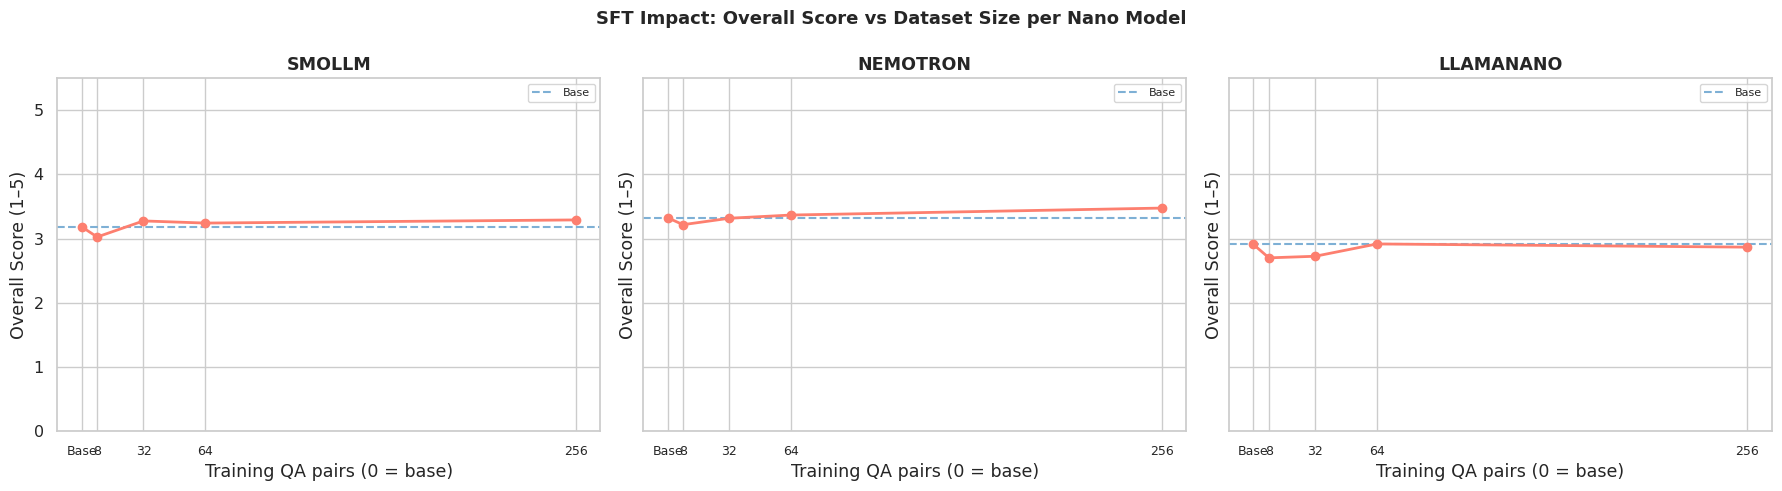

Saved → figures/fig1_sft_dataset_size.png


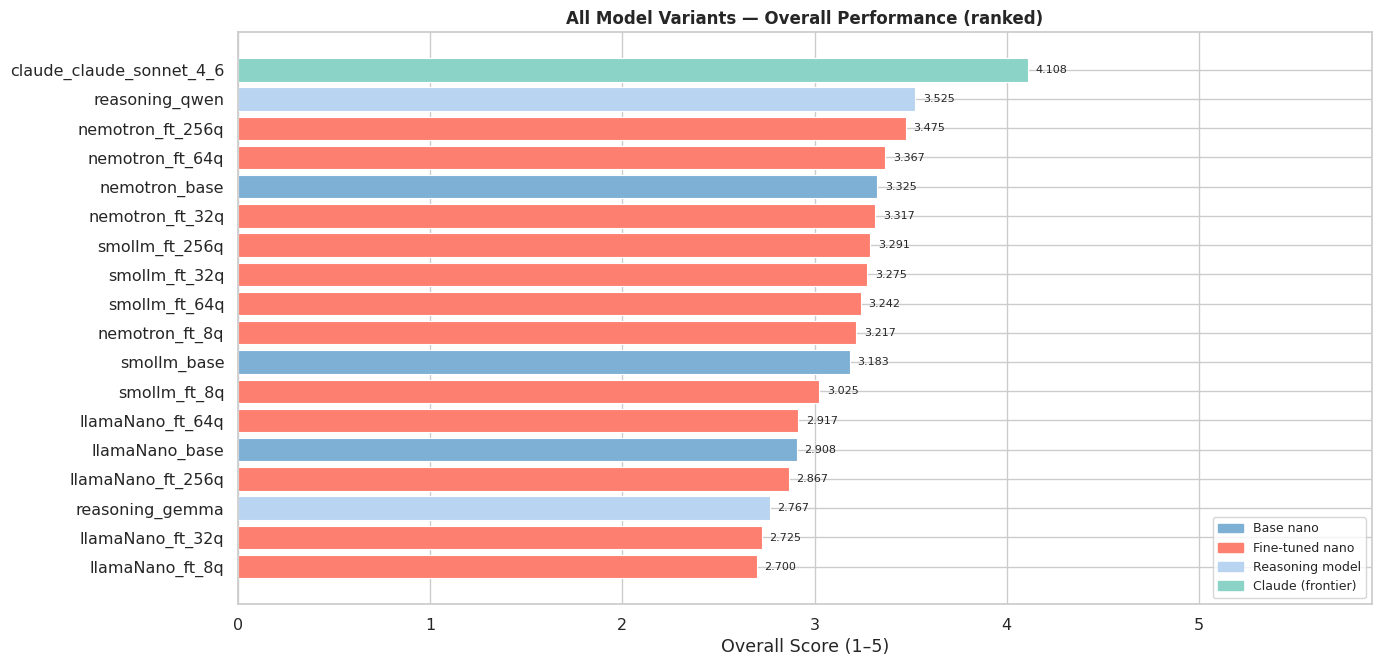

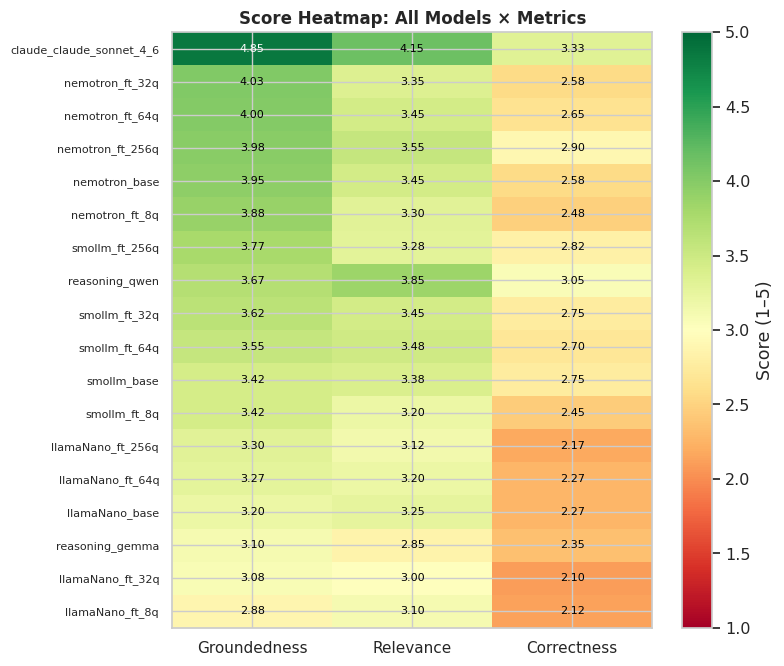

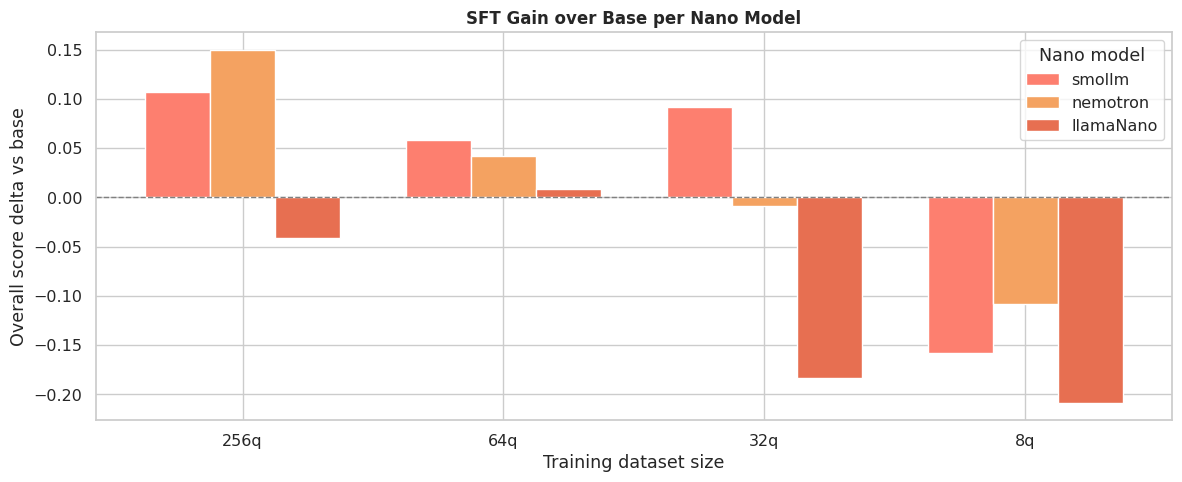

All figures saved to figures/


In [25]:
# Config A.

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)
METRICS = ["groundedness", "relevance", "correctness"]

# Load summary from disk if not in memory
if "summary_df" not in dir():
    summary_df = pd.read_csv("data/eval_summary.csv", index_col="model")

if "all_eval_results" not in dir() or not all_eval_results:
    all_eval_results = {}
    for f in sorted(EVAL_DIR.glob("*.jsonl")):
        with jsonlines.open(f) as reader:
            all_eval_results[f.stem] = list(reader)

sns.set_theme(style="whitegrid", font_scale=1.05)

def model_color(label):
    if "claude" in label:        return "#8bd3c7"
    if "reasoning" in label:     return "#b8d4f0"
    if "_ft_" in label:          return "#fd7f6f"
    return "#7eb0d5"  # base nano

# ════════════════════════════════════════════════════════════════════════════
# FIGURE 1: SFT dataset size effect per nano model
# X-axis: 0=base, then 8, 32, 64, 256 QA pairs
# ════════════════════════════════════════════════════════════════════════════
fig1, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig1.suptitle("SFT Impact: Overall Score vs Dataset Size per Nano Model",
              fontsize=13, fontweight="bold")

for ax, nano_key in zip(axes, NANO_MODELS.keys()):
    xs, ys = [0], []
    base_label = f"{nano_key}_base"
    base_score = summary_df.loc[base_label, "overall"] if base_label in summary_df.index else None
    if base_score is not None:
        ys.append(base_score)
    for size in sorted(DATASET_SIZES):
        ft_label = f"{nano_key}_ft_{size}q"
        if ft_label in summary_df.index:
            xs.append(size)
            ys.append(summary_df.loc[ft_label, "overall"])

    ax.plot(xs, ys, marker="o", linewidth=2, color="#fd7f6f", zorder=3)
    if base_score:
        ax.axhline(base_score, linestyle="--", color="#7eb0d5", linewidth=1.5, label="Base")
    ax.set_title(nano_key.upper(), fontweight="bold")
    ax.set_xlabel("Training QA pairs (0 = base)")
    ax.set_ylabel("Overall Score (1–5)")
    ax.set_xticks(xs)
    ax.set_xticklabels(["Base"] + [str(s) for s in sorted(DATASET_SIZES)], fontsize=9)
    ax.set_ylim(0, 5.5)
    ax.legend(fontsize=8)

plt.tight_layout()
fig1.savefig(FIGURES_DIR / "fig1_sft_dataset_size.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {FIGURES_DIR}/fig1_sft_dataset_size.png")

# ════════════════════════════════════════════════════════════════════════════
# FIGURE 2: Horizontal bar — all model variants ranked by overall score
# ════════════════════════════════════════════════════════════════════════════
fig2, ax = plt.subplots(figsize=(14, max(6, len(summary_df) * 0.38)))
sorted_df = summary_df.sort_values("overall", ascending=True)
colors    = [model_color(idx) for idx in sorted_df.index]
bars = ax.barh(sorted_df.index, sorted_df["overall"],
               color=colors, edgecolor="white", linewidth=0.8)
for bar, val in zip(bars, sorted_df["overall"]):
    ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=8)
ax.set_xlabel("Overall Score (1–5)")
ax.set_title("All Model Variants — Overall Performance (ranked)",
             fontsize=12, fontweight="bold")
ax.set_xlim(0, 5.9)
from matplotlib.patches import Patch
legend_handles = [
    Patch(color="#7eb0d5", label="Base nano"),
    Patch(color="#fd7f6f", label="Fine-tuned nano"),
    Patch(color="#b8d4f0", label="Reasoning model"),
    Patch(color="#8bd3c7", label="Claude (frontier)"),
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=9)
plt.tight_layout()
fig2.savefig(FIGURES_DIR / "fig2_all_models_ranked.png", dpi=150, bbox_inches="tight")
plt.show()

# ════════════════════════════════════════════════════════════════════════════
# FIGURE 3: Heatmap — all models × 3 metrics
# ════════════════════════════════════════════════════════════════════════════
heat_data = summary_df[METRICS].sort_values("groundedness", ascending=False)
fig3, ax  = plt.subplots(figsize=(8, max(6, len(heat_data) * 0.38)))
im = ax.imshow(heat_data.values.astype(float), cmap="RdYlGn",
               aspect="auto", vmin=1, vmax=5)
ax.set_xticks(range(len(METRICS)))
ax.set_xticklabels([m.capitalize() for m in METRICS], fontsize=11)
ax.set_yticks(range(len(heat_data)))
ax.set_yticklabels(heat_data.index, fontsize=8)
for i in range(len(heat_data)):
    for j in range(len(METRICS)):
        v = heat_data.values[i, j]
        ax.text(j, i, f"{float(v):.2f}", ha="center", va="center", fontsize=8,
                color="black" if 2 < float(v) < 4.5 else "white")
plt.colorbar(im, ax=ax, label="Score (1–5)")
ax.set_title("Score Heatmap: All Models × Metrics", fontsize=12, fontweight="bold")
plt.tight_layout()
fig3.savefig(FIGURES_DIR / "fig3_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# ════════════════════════════════════════════════════════════════════════════
# FIGURE 4: Average FT gain per nano model (bar) — dataset size on x-axis
# ════════════════════════════════════════════════════════════════════════════
fig4, ax = plt.subplots(figsize=(12, 5))
width = 0.25
x     = np.arange(len(DATASET_SIZES))
colors_nano = ["#fd7f6f", "#f4a261", "#e76f51"]

for i, nano_key in enumerate(NANO_MODELS.keys()):
    base_label = f"{nano_key}_base"
    base_s = summary_df.loc[base_label, "overall"] if base_label in summary_df.index else 0
    gains  = []
    for size in DATASET_SIZES:
        ft_label = f"{nano_key}_ft_{size}q"
        ft_s = summary_df.loc[ft_label, "overall"] if ft_label in summary_df.index else base_s
        gains.append(ft_s - base_s)
    ax.bar(x + i * width, gains, width=width, label=nano_key, color=colors_nano[i], edgecolor="white")

ax.axhline(0, color="gray", linewidth=1, linestyle="--")
ax.set_xticks(x + width)
ax.set_xticklabels([f"{s}q" for s in DATASET_SIZES])
ax.set_xlabel("Training dataset size")
ax.set_ylabel("Overall score delta vs base")
ax.set_title("SFT Gain over Base per Nano Model", fontsize=12, fontweight="bold")
ax.legend(title="Nano model")
plt.tight_layout()
fig4.savefig(FIGURES_DIR / "fig4_sft_gain_per_model.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\n\nAll figures saved to {FIGURES_DIR}/")


## B. Discussion

In [26]:
# Config B.

if "summary_df" not in dir():
    summary_df = pd.read_csv("data/eval_summary.csv", index_col="model")

METRICS = ["groundedness", "relevance", "correctness"]

def score(label, metric="overall"):
    return summary_df.loc[label, metric] if label in summary_df.index else float("nan")

def ft_delta(nano_key, size, metric="overall"):
    return score(f"{nano_key}_ft_{size}q", metric) - score(f"{nano_key}_base", metric)

ft_labels     = [idx for idx in summary_df.index if "_ft_" in idx]
base_labels   = [idx for idx in summary_df.index if "_base" in idx]
reason_labels = [idx for idx in summary_df.index if "reasoning_" in idx]
claude_labels = [idx for idx in summary_df.index if "claude" in idx]
best_overall  = summary_df["overall"].idxmax()

sep = "=" * 75
print(sep)
print("RESULTS NARRATIVE — AAI-590")
print(sep)

print(f"""
EXPERIMENT OVERVIEW
───────────────────
  Nano models      : {", ".join(NANO_MODELS.keys())}
  Fine-tuned runs  : {len(NANO_MODELS)} models x {len(DATASET_SIZES)} dataset sizes = {len(NANO_MODELS)*len(DATASET_SIZES)} variants
  Reasoning models : {", ".join(REASONING_MODELS.keys())} (RAG baseline)
  Frontier model   : Claude ({CLAUDE_MODEL})
  Test set         : {NUM_TEST} held-out questions
  Eval framework   : Microsoft Azure AI Foundry (1-5 scale)

QA DATASET GENERATION
─────────────────────
  QA pairs per reasoning model : {QA_PER_MODEL}
  Total combined               : {QA_PER_MODEL * len(REASONING_MODELS)}
  Held-out test                : {NUM_TEST}
  Available for training       : {QA_PER_MODEL * len(REASONING_MODELS) - NUM_TEST}
  Training splits              : {DATASET_SIZES}
""")

print("EVALUATION SUMMARY")
print("─" * 50)
print(summary_df.round(3).to_string())
print()
print(f"BEST MODEL: {best_overall}  (overall {score(best_overall):.3f})")
print()

print("SFT DATASET SIZE EFFECT")
print("─" * 50)
for nano_key in NANO_MODELS.keys():
    base_s = score(f"{nano_key}_base")
    print(f"  {nano_key} base: {base_s:.3f}")
    for size in DATASET_SIZES:
        d     = ft_delta(nano_key, size)
        ft_s  = score(f"{nano_key}_ft_{size}q")
        arrow = "UP" if d > 0 else ("DOWN" if d < 0 else "--")
        print(f"    -> ft {size:>3}q : {ft_s:.3f}  ({arrow} {d:+.3f} vs base)")
print()

print("AVERAGE FT GAIN ACROSS ALL NANO MODELS (by dataset size)")
print("─" * 50)
for size in DATASET_SIZES:
    gains = [ft_delta(k, size) for k in NANO_MODELS]
    valid = [g for g in gains if not pd.isna(g)]
    avg_g = sum(valid) / len(valid) if valid else float("nan")
    arrow = "UP" if avg_g > 0 else ("DOWN" if avg_g < 0 else "--")
    print(f"  {size:>3}q : avg gain {arrow} {avg_g:+.3f}")
print()

print("FRONTIER COMPARISON")
print("─" * 50)
best_ft_score = summary_df.loc[ft_labels, "overall"].max() if ft_labels else float("nan")
best_ft_label = summary_df.loc[ft_labels, "overall"].idxmax() if ft_labels else "N/A"
for cl in claude_labels:
    cl_score = score(cl)
    print(f"  Claude ({CLAUDE_MODEL})     : {cl_score:.3f}")
print(f"  Best fine-tuned nano      : {best_ft_score:.3f}  ({best_ft_label})")
print(f"  Gap                       : {cl_score - best_ft_score:+.3f}")
for rm in reason_labels:
    print(f"  Reasoning [{rm}] : {score(rm):.3f}")
print(sep)


RESULTS NARRATIVE — AAI-590

EXPERIMENT OVERVIEW
───────────────────
  Nano models      : smollm, nemotron, llamaNano
  Fine-tuned runs  : 3 models x 4 dataset sizes = 12 variants
  Reasoning models : qwen, gemma (RAG baseline)
  Frontier model   : Claude (claude-sonnet-4-6)
  Test set         : 40 held-out questions
  Eval framework   : Microsoft Azure AI Foundry (1-5 scale)

QA DATASET GENERATION
─────────────────────
  QA pairs per reasoning model : 150
  Total combined               : 300
  Held-out test                : 40
  Available for training       : 260
  Training splits              : [256, 64, 32, 8]

EVALUATION SUMMARY
──────────────────────────────────────────────────
                          groundedness  relevance  correctness  overall
model                                                                  
claude_claude_sonnet_4_6         4.850      4.150        3.325    4.108
reasoning_qwen                   3.675      3.850        3.050    3.525
nemotron_ft_256q    

In [27]:
# Meta data

#Export into a csv raw eval data (path)
EVAL_DIR = Path("data/eval")

# Collect all model files
all_eval_data = []

for model_file in EVAL_DIR.glob("*.jsonl"):
    model_name = model_file.stem  # e.g., "llamaNano_base", "nemotron_ft_256q"
    print(f"Loading {model_file.name}...")

    for line in open(model_file):
        try:
            row = json.loads(line.strip())
            row["model"] = model_name  # Add model column
            all_eval_data.append(row)
        except json.JSONDecodeError:
            continue  # Skip malformed lines

# Create unified DataFrame
df = pd.DataFrame(all_eval_data)
print(f"\n✅ Merged {len(df)} evaluation rows from {len(list(EVAL_DIR.glob('*.jsonl')))} models")

# Save full database
df.to_csv("data/full_eval_database.csv", index=False)
df.to_json("data/full_eval_database.jsonl", orient="records", lines=True)

print("Saved to:")
print("  - full_eval_database.csv")
print("  - full_eval_database.jsonl")

Loading reasoning_qwen.jsonl...
Loading smollm_ft_64q.jsonl...
Loading reasoning_gemma.jsonl...
Loading smollm_ft_256q.jsonl...
Loading smollm_ft_8q.jsonl...
Loading nemotron_ft_256q.jsonl...
Loading llamaNano_ft_256q.jsonl...
Loading llamaNano_base.jsonl...
Loading nemotron_base.jsonl...
Loading smollm_base.jsonl...
Loading smollm_ft_32q.jsonl...
Loading llamaNano_ft_32q.jsonl...
Loading claude_claude_sonnet_4_6.jsonl...
Loading llamaNano_ft_64q.jsonl...
Loading llamaNano_ft_8q.jsonl...
Loading nemotron_ft_8q.jsonl...
Loading nemotron_ft_32q.jsonl...
Loading nemotron_ft_64q.jsonl...

✅ Merged 720 evaluation rows from 18 models
Saved to:
  - full_eval_database.csv
  - full_eval_database.jsonl


In [29]:
# Compute overall (mean of 3 metrics)
df['overall'] = df[['groundedness', 'relevance', 'correctness']].mean(axis=1)

# Now rankings work
print("\nTop 5 models (overall):")
print(df.groupby('model')['overall'].mean().sort_values(ascending=False).head())

# Save updated database
df.to_csv("data/full_eval_database.csv", index=False)
print("✅ Added 'overall' column → saved")


Top 5 models (overall):
model
claude_claude_sonnet_4_6    4.108333
reasoning_qwen              3.525000
nemotron_ft_256q            3.475000
nemotron_ft_64q             3.366667
nemotron_base               3.325000
Name: overall, dtype: float64
✅ Added 'overall' column → saved


In [30]:
print("📊 FULL BREAKDOWN")
print("="*50)
print(f"Rows: {len(df):,}")
print(f"Models: {df['model'].nunique()}")
print(f"Questions: {df['question'].nunique()}")

# Per-metric rankings
metrics = ['groundedness', 'relevance', 'correctness', 'overall']
for metric in metrics:
    print(f"\n🏆 Top 3 {metric}:")
    print(df.groupby('model')[metric].mean().nlargest(3))

print("\n📈 Score distributions:")
print(df[['groundedness', 'relevance', 'correctness', 'overall']].describe())

📊 FULL BREAKDOWN
Rows: 720
Models: 18
Questions: 40

🏆 Top 3 groundedness:
model
claude_claude_sonnet_4_6    4.850
nemotron_ft_32q             4.025
nemotron_ft_64q             4.000
Name: groundedness, dtype: float64

🏆 Top 3 relevance:
model
claude_claude_sonnet_4_6    4.15
reasoning_qwen              3.85
nemotron_ft_256q            3.55
Name: relevance, dtype: float64

🏆 Top 3 correctness:
model
claude_claude_sonnet_4_6    3.325
reasoning_qwen              3.050
nemotron_ft_256q            2.900
Name: correctness, dtype: float64

🏆 Top 3 overall:
model
claude_claude_sonnet_4_6    4.108333
reasoning_qwen              3.525000
nemotron_ft_256q            3.475000
Name: overall, dtype: float64

📈 Score distributions:
       groundedness  relevance  correctness     overall
count    719.000000  719.00000   719.000000  719.000000
mean       3.609179    3.35605     2.573018    3.179416
std        1.493337    1.34602     1.547717    1.335577
min        1.000000    1.00000     1.000000    1

## Summary

This experiment evaluated Retrieval-Augmented Generation (RAG) across **18 model variants** on a domain-specific corpus. The primary research question is whether the *size of the SFT training dataset* meaningfully impacts RAG quality, and whether this effect is consistent across different nano-model architectures.

---

## Methodology Summary

| Component | Detail |
|---|---|
| Corpus | Azure AI Foundry documentation (PDF) |
| Retriever | FAISS + `all-MiniLM-L6-v2` embeddings, top-5 chunks |
| QA Generation | Qwen3-30B-Thinking + DeepSeek-V3 (150 pairs each = 300 total) |
| Dataset splits | Train: 256 / 64 / 32 / 8 QA pairs · Test: 40 held-out questions |
| Nano models | SmolLM3-3B · Nemotron-Mini-4B · Llama-4-Maverick (3 architectures) |
| Fine-tuning | LoRA SFT (r=16, α=32, 3 epochs, cosine LR) · 12 total runs |
| Reasoning baselines | Qwen3-30B-Thinking · DeepSeek-V3 (RAG, no fine-tuning) |
| Frontier baseline | Claude (`claude-sonnet-4-6`) via API |
| Evaluation model | Claude (`claude-sonnet-4-6`) · 40 held-out questions |
| Eval scale | Microsoft Azure AI Foundry 1–5 metrics |
| Total variants | 3 base + 12 FT + 2 reasoning + 1 Claude = **18** |

---

## Key Questions

1. **Dataset size effect**: Does more SFT data (8 → 256 QA pairs) produce better RAG quality?
2. **Cross-architecture consistency**: Is the dataset-size effect consistent across SmolLM3-3B, Nemotron-Mini-4B, and Llama-4-Maverick?
3. **Nano vs reasoning models**: Can fine-tuned 3–4B models match or approach 30B+ reasoning models on RAG tasks?
4. **Frontier gap**: How far does the best fine-tuned nano model sit from Claude?

---

## Metric Definitions

### Groundedness
Whether the response is supported by retrieved context — measures hallucination resistance and instruction-following.

### Relevance
Whether the response directly addresses the question. SFT on domain-specific QA pairs targets this by training the model to answer concisely rather than summarize broadly.

### Correctness
Agreement with the ground-truth answer. The most demanding metric — requires both effective retrieval and accurate generation. Most directly reflects the value of domain-specific fine-tuning.

---

## Analysis

### Dataset Size Effect
The four training splits (8 / 32 / 64 / 256 QA pairs) isolate the effect of data quantity. The key question is where the inflection point lies and whether small splits (8–32) already capture most of the gain.

### Cross-Architecture Consistency
Using three nano models ensures observed trends are not artifacts of a single architecture. If all three show the same dataset-size curve, the finding is more generalisable.

### Nano vs Reasoning Models
Reasoning models (30B+) serve as strong baselines. The gap between fine-tuned nanos and reasoning models quantifies the capability distance attributable to scale, independent of domain adaptation.

### Frontier Gap
Claude operates via API at inference cost per token. A small performance gap between Claude and the best fine-tuned nano model would be practically significant in cost- and latency-constrained deployments.
